# E-commerce Customer Segmentation — Exploratory Modeling

This notebook documents the modeling path used to identify an interpretable customer segmentation for an e-commerce dataset.

The analysis begins with a broad behavioral feature set, tests sensitivity to influential variables, evaluates alternative clustering assumptions, and then narrows the final segmentation to **RFM (Recency, Frequency, Monetary)** features.

**Business objective:** identify customer groups that differ in purchasing value and behavior so they can support retention, re-engagement, cross-sell and upsell decisions.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency

DATA_PATH = Path("../data/ecommerce_consumer_behavior.csv")
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1000, 28)
Columns: ['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Location', 'Purchase_Category', 'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence', 'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision']


## 1. Data understanding

The dataset combines demographics, purchase behavior, product and channel attributes, engagement, loyalty, satisfaction and purchase-intent fields.

Several fields are deliberately excluded from cluster formation:

- `Customer_ID` is a technical identifier.
- `Location` has high cardinality and limited value for the core customer-value objective.
- Product-specific fields describe *what* was purchased rather than the customer's overall purchasing behavior.
- `Customer_Satisfaction` and `Purchase_Intent` are reserved for post-hoc analysis.

In [2]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique(dropna=False),
})
summary.sort_values(["missing", "unique_values"], ascending=[False, False]).head(15)

,dtype,missing,unique_values
Engagement_with_Ads,object,256,4
Social_Media_Influence,object,247,4
Customer_ID,object,0,1000
Purchase_Amount,object,0,989
Location,object,0,969
Time_of_Purchase,object,0,344
Age,int64,0,33
Purchase_Category,object,0,24
Time_to_Decision,int64,0,14
Time_Spent_on_Product_Research(hours),float64,0,12


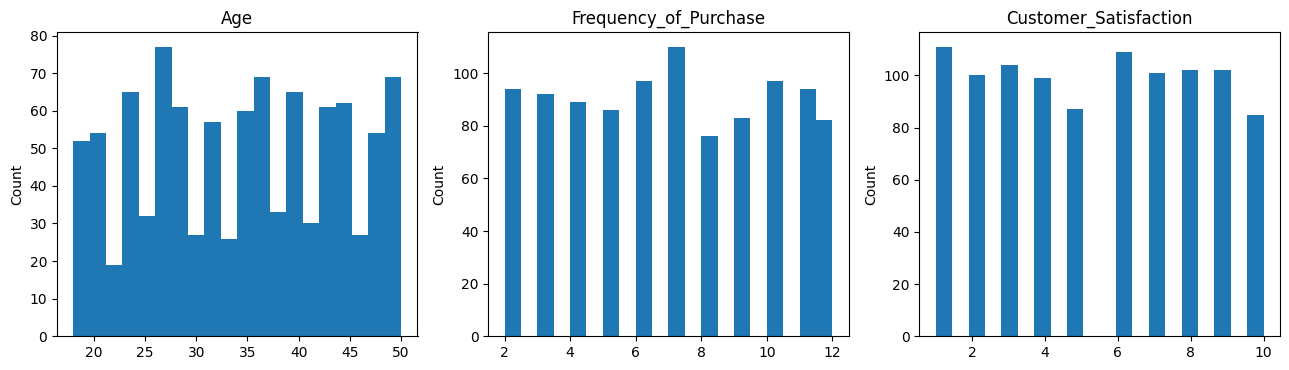

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col in zip(axes, ["Age", "Frequency_of_Purchase", "Customer_Satisfaction"]):
    ax.hist(df[col].dropna(), bins=20)
    ax.set_title(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 2. Feature engineering

The preprocessing mirrors the decisions made during the research workflow:

- clean purchase amount from currency text to numeric;
- derive **Recency** using a fixed observation date for reproducibility;
- retain **Frequency** and **Monetary** as direct customer-value measures;
- encode social influence, ad engagement and discount sensitivity as ordered scales;
- convert binary loyalty/discount indicators to 0/1;
- keep satisfaction and purchase intent outside the modeling matrix.

In [4]:
reference_date = pd.Timestamp("2024-12-31")
monetary = (df["Purchase_Amount"].astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip().astype(float))
purchase_date = pd.to_datetime(df["Time_of_Purchase"], format="mixed", errors="raise")

engineered = pd.DataFrame(index=df.index)
engineered["RECENCY"] = (reference_date - purchase_date).dt.days.clip(lower=0)
engineered["FREQUENCY"] = df["Frequency_of_Purchase"].astype(float)
engineered["MONETARY"] = monetary
engineered["Research_Time"] = df["Time_Spent_on_Product_Research(hours)"].astype(float)
engineered["Return_Rate"] = df["Return_Rate"].astype(float)
engineered["Time_to_Decision"] = df["Time_to_Decision"].astype(float)
engineered["Discount_Used"] = df["Discount_Used"].astype(float)
engineered["Loyalty_Program"] = df["Customer_Loyalty_Program_Member"].astype(float)

ordinal_map = {"LOW":0.33, "MEDIUM":0.66, "HIGH":1.0}
discount_map = {"NOT SENSITIVE":0.0, "SOMEWHAT SENSITIVE":0.5, "VERY SENSITIVE":1.0}

def encode_ordinal(series, mapping):
    return (series.astype(str).str.strip().str.upper().map(mapping).fillna(0.0))

engineered["Social_Media_Influence"] = encode_ordinal(df["Social_Media_Influence"], ordinal_map)
engineered["Engagement_with_Ads"] = encode_ordinal(df["Engagement_with_Ads"], ordinal_map)
engineered["Discount_Sensitivity"] = encode_ordinal(df["Discount_Sensitivity"], discount_map)

scaled = pd.DataFrame(MinMaxScaler().fit_transform(engineered), columns=engineered.columns, index=engineered.index)
print("Broad behavioral feature matrix:", scaled.shape)
scaled.head()

Broad behavioral feature matrix: (1000, 11)


,RECENCY,FREQUENCY,MONETARY,Research_Time,Return_Rate,Time_to_Decision,Discount_Used,Loyalty_Program,Social_Media_Influence,Engagement_with_Ads,Discount_Sensitivity
0,0.835165,0.2,0.632434,1.00,0.5,0.076923,1.0,0.0,0.00,0.00,0.5
1,0.708791,0.9,0.383160,1.00,0.5,0.384615,1.0,0.0,0.66,1.00,0.0
2,0.796703,0.0,0.838904,0.15,0.5,0.153846,1.0,1.0,0.33,0.33,0.0
3,0.239011,0.4,0.113042,0.50,0.0,0.692308,1.0,1.0,1.00,0.00,0.5
4,0.920330,0.4,0.359658,0.00,1.0,0.230769,0.0,0.0,0.66,0.00,0.0


## 3. Broad behavioral K-Means model

The first compact model uses RFM plus engagement, loyalty, discount and decision-behavior variables. This checks whether a richer behavioral representation produces clear segments.

In [5]:
def evaluate_kmeans_range(X, k_values=range(2, 9)):
    rows=[]
    for k in k_values:
        m=KMeans(n_clusters=k, random_state=42, n_init=50)
        lab=m.fit_predict(X)
        rows.append({"k":k,"inertia":m.inertia_,"silhouette":silhouette_score(X,lab),"davies_bouldin":davies_bouldin_score(X,lab)})
    return pd.DataFrame(rows)

broad_metrics=evaluate_kmeans_range(scaled)
broad_metrics.round(3)

,k,inertia,silhouette,davies_bouldin
0,2,1381.953,0.152,2.323
1,3,1251.854,0.134,2.065
2,4,1130.219,0.174,2.093
3,5,1093.383,0.145,2.293
4,6,1057.569,0.122,2.405
5,7,1024.538,0.117,2.564
6,8,992.752,0.113,2.653


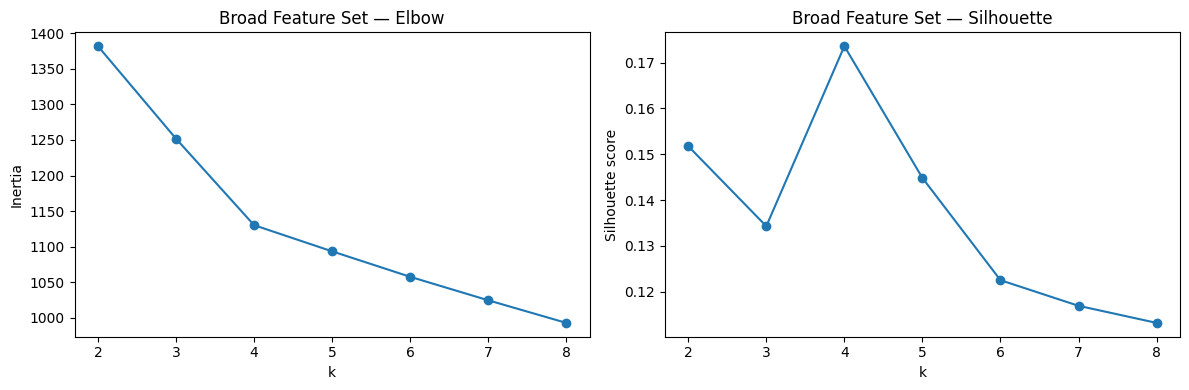

In [6]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(broad_metrics["k"], broad_metrics["inertia"], marker="o")
axes[0].set_title("Broad Feature Set — Elbow"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(broad_metrics["k"], broad_metrics["silhouette"], marker="o")
axes[1].set_title("Broad Feature Set — Silhouette"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout(); plt.show()

### Sensitivity to discount and loyalty

Discount usage and loyalty-program membership can dominate customer-group boundaries. The next test removes those fields and checks how much the geometry changes.

In [7]:
reduced = scaled.drop(columns=["Discount_Used", "Loyalty_Program"])
reduced_metrics = evaluate_kmeans_range(reduced)
comparison = broad_metrics[["k","silhouette"]].merge(reduced_metrics[["k","silhouette"]], on="k", suffixes=("_broad","_without_discount_loyalty"))
comparison.round(3)

,k,silhouette_broad,silhouette_without_discount_loyalty
0,2,0.152,0.112
1,3,0.134,0.102
2,4,0.174,0.109
3,5,0.145,0.105
4,6,0.122,0.103
5,7,0.117,0.104
6,8,0.113,0.107


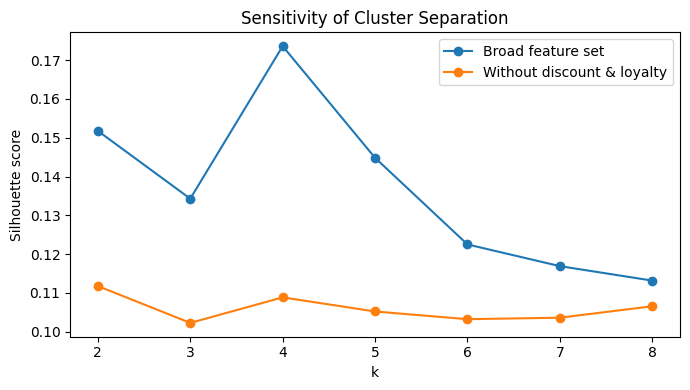

In [8]:
plt.figure(figsize=(7,4))
plt.plot(comparison["k"], comparison["silhouette_broad"], marker="o", label="Broad feature set")
plt.plot(comparison["k"], comparison["silhouette_without_discount_loyalty"], marker="o", label="Without discount & loyalty")
plt.xlabel("k"); plt.ylabel("Silhouette score"); plt.title("Sensitivity of Cluster Separation"); plt.legend(); plt.tight_layout(); plt.show()

The sensitivity analysis motivates a simpler value-based model: if operational variables materially change the solution, clusters may represent campaign mechanics rather than durable customer-value profiles.

## 4. Outlier diagnostic with Isolation Forest

In [9]:
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_flag = iso.fit_predict(scaled)
print("Outlier flag counts (-1 = flagged):")
print(pd.Series(outlier_flag).value_counts())
(engineered.assign(outlier=outlier_flag)
 .groupby("outlier")[["RECENCY","FREQUENCY","MONETARY"]]
 .agg(["mean","median","count"]).round(2))

Outlier flag counts (-1 = flagged):
 1    950
-1     50
Name: count, dtype: int64


RECENCY              FREQUENCY              MONETARY              
           mean median count      mean median count     mean  median count
outlier                                                                   
-1       192.12  226.5    50      7.16    8.5    50   215.44  123.38    50
 1       184.34  183.0   950      6.93    7.0   950   278.20  278.64   950

The outlier test is diagnostic only. The final model retains the full dataset rather than removing observations solely because they are unusual in the broad feature space.

## 5. Soft-clustering comparison: GMM + PCA

A Gaussian Mixture Model is tested because customer behavior may overlap rather than form perfectly separated spherical groups. PCA first retains 90% of the variance while reducing redundancy.

In [10]:
pca=PCA(n_components=0.90, random_state=42)
X_pca=pca.fit_transform(scaled)
print("PCA components:", X_pca.shape[1])
print("Explained variance retained:", round(pca.explained_variance_ratio_.sum(),3))
rows=[]
for k in range(2,9):
    g=GaussianMixture(n_components=k,covariance_type="full",random_state=42)
    lab=g.fit_predict(X_pca)
    rows.append({"k":k,"AIC":g.aic(X_pca),"BIC":g.bic(X_pca),"silhouette_pca":silhouette_score(X_pca,lab)})
gmm_metrics=pd.DataFrame(rows)
gmm_metrics.round(2)

PCA components: 9
Explained variance retained: 0.903


,k,AIC,BIC,silhouette_pca
0,2,4255.17,4790.12,0.17
1,3,1228.26,2033.13,0.15
2,4,-1703.42,-628.62,0.20
3,5,-1696.17,-351.45,0.16
4,6,-2596.98,-982.33,0.15
5,7,-2602.34,-717.76,0.14
6,8,-2692.01,-537.51,0.13


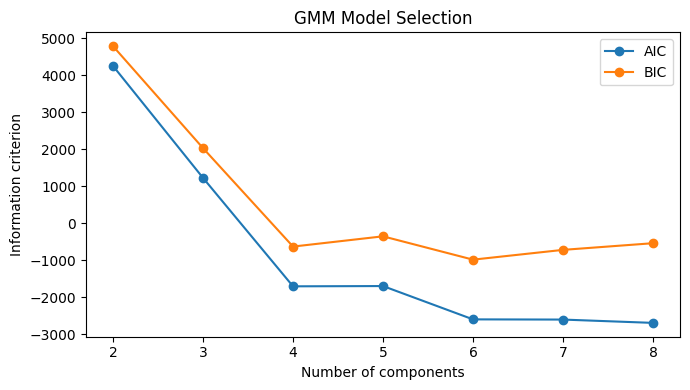

Best K by BIC: 6


In [11]:
plt.figure(figsize=(7,4))
plt.plot(gmm_metrics["k"],gmm_metrics["AIC"],marker="o",label="AIC")
plt.plot(gmm_metrics["k"],gmm_metrics["BIC"],marker="o",label="BIC")
plt.xlabel("Number of components"); plt.ylabel("Information criterion"); plt.title("GMM Model Selection"); plt.legend(); plt.tight_layout(); plt.show()
best_gmm_k=int(gmm_metrics.loc[gmm_metrics["BIC"].idxmin(),"k"])
print("Best K by BIC:",best_gmm_k)

In [12]:
gmm_labelings=[]
for seed in range(5):
    g=GaussianMixture(n_components=best_gmm_k,covariance_type="full",random_state=seed)
    gmm_labelings.append(g.fit_predict(X_pca))
gmm_aris=[adjusted_rand_score(gmm_labelings[i],gmm_labelings[j]) for i in range(5) for j in range(i+1,5)]
print("GMM mean pairwise ARI:",round(float(np.mean(gmm_aris)),3))
print("GMM ARI std:",round(float(np.std(gmm_aris)),3))

GMM mean pairwise ARI: 0.687
GMM ARI std: 0.077


The GMM comparison shows that the data can sustain a more granular probabilistic segmentation. For the business objective, however, a smaller set of directly interpretable customer-value groups is preferable.

## 6. Final segmentation: RFM + K-Means

The final model narrows the clustering space to the three most direct customer-value dimensions: Recency, Frequency and Monetary. Other variables remain available for profiling after cluster formation.

In [13]:
rfm_raw=engineered[["RECENCY","FREQUENCY","MONETARY"]].copy()
rfm_scaled=pd.DataFrame(MinMaxScaler().fit_transform(rfm_raw),columns=rfm_raw.columns,index=rfm_raw.index)
rfm_metrics=evaluate_kmeans_range(rfm_scaled)
rfm_metrics.round(3)

,k,inertia,silhouette,davies_bouldin
0,2,187.362,0.265,1.510
1,3,146.870,0.262,1.243
2,4,115.910,0.289,1.128
3,5,98.809,0.282,1.081
4,6,84.884,0.285,1.020
5,7,74.104,0.282,1.027
6,8,65.220,0.282,1.025


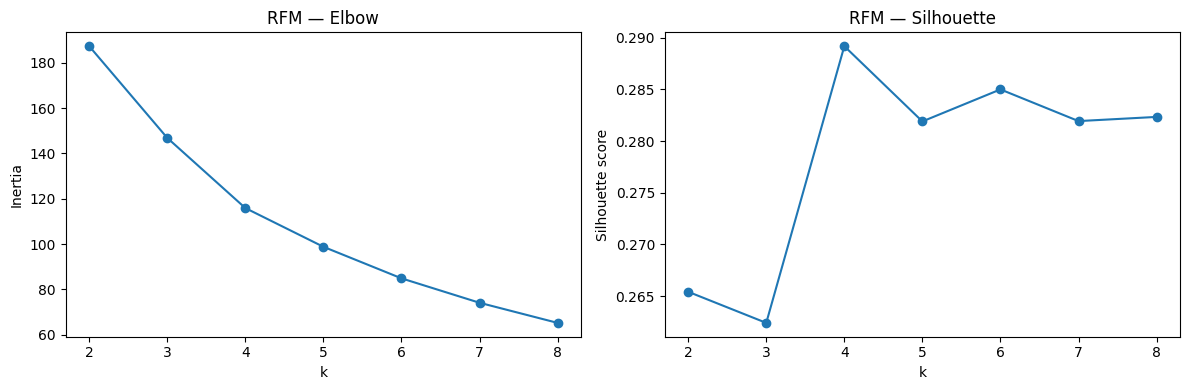

In [14]:
fig, axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(rfm_metrics["k"],rfm_metrics["inertia"],marker="o"); axes[0].set_title("RFM — Elbow"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(rfm_metrics["k"],rfm_metrics["silhouette"],marker="o"); axes[1].set_title("RFM — Silhouette"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout(); plt.show()

The RFM silhouette curve has a clear maximum at **K=4** in the evaluated range, and four segments remain compact enough to translate into distinct customer strategies.

In [15]:
final_model=KMeans(n_clusters=4,random_state=42,n_init=50)
cluster=final_model.fit_predict(rfm_scaled)
seed_labels=[KMeans(n_clusters=4,random_state=s,n_init=20).fit_predict(rfm_scaled) for s in range(5)]
seed_aris=[adjusted_rand_score(seed_labels[i],seed_labels[j]) for i in range(5) for j in range(i+1,5)]
pd.DataFrame([{
    "K":4,
    "Silhouette":silhouette_score(rfm_scaled,cluster),
    "Davies_Bouldin":davies_bouldin_score(rfm_scaled,cluster),
    "Mean_Pairwise_ARI":np.mean(seed_aris),
    "ARI_Std":np.std(seed_aris),
}]).round(3)

,K,Silhouette,Davies_Bouldin,Mean_Pairwise_ARI,ARI_Std
0,4,0.289,1.128,0.98,0.012


## 7. Cluster profiles

In [16]:
profile=(rfm_raw.assign(cluster=cluster)
 .groupby("cluster")
 .agg(customers=("RECENCY","size"),recency_days=("RECENCY","mean"),frequency=("FREQUENCY","mean"),monetary=("MONETARY","mean"))
 .round(2))
profile

,customers,recency_days,frequency,monetary
cluster,,,,
0,261,156.26,9.08,406.58
1,264,213.48,9.66,160.71
2,226,278.26,4.39,328.50
3,249,99.19,4.14,209.95


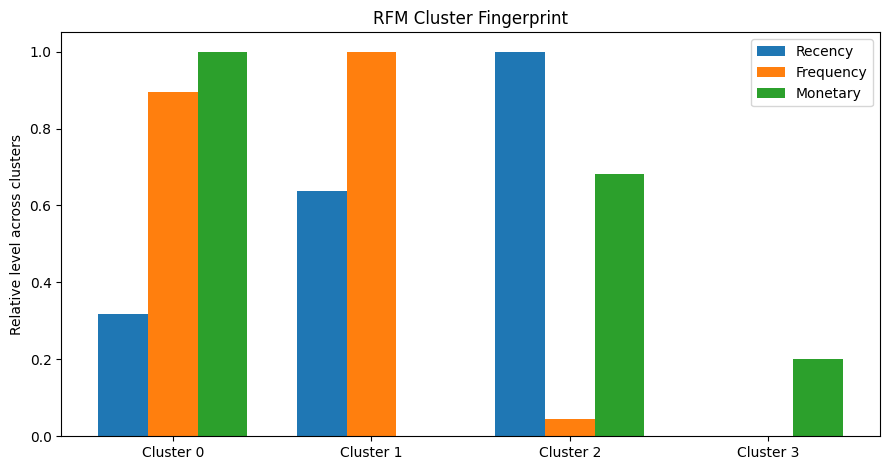

In [17]:
profile_norm=profile[["recency_days","frequency","monetary"]].copy()
profile_norm=(profile_norm-profile_norm.min())/(profile_norm.max()-profile_norm.min())
x=np.arange(len(profile_norm)); width=0.25
plt.figure(figsize=(9,4.8))
plt.bar(x-width,profile_norm["recency_days"],width,label="Recency")
plt.bar(x,profile_norm["frequency"],width,label="Frequency")
plt.bar(x+width,profile_norm["monetary"],width,label="Monetary")
plt.xticks(x,[f"Cluster {i}" for i in profile_norm.index]); plt.ylabel("Relative level across clusters"); plt.title("RFM Cluster Fingerprint"); plt.legend(); plt.tight_layout(); plt.show()

### Segment interpretation

| Cluster | Segment | Interpretation |
|---|---|---|
| 0 | **High-Value Repeat Customers** | High frequency and the highest average spend; important retention and cross-sell segment. |
| 1 | **Frequent Low-Spend Customers** | Very frequent purchasing but low average monetary value; opportunity to increase basket size. |
| 2 | **Lapsed High-Spend Customers** | Meaningful historical spend but the oldest average recency and lower frequency; strongest win-back candidate. |
| 3 | **Recent Occasional Customers** | Most recent purchases but low frequency; opportunity to encourage the next purchase and build habit. |

The names are business interpretations of the observed RFM profiles, not predefined labels.

## 8. Post-hoc validation

`Customer_Satisfaction` and `Purchase_Intent` are added only after clustering, so they do not influence the segment boundaries.

In [18]:
evaluation=pd.DataFrame({"cluster":cluster,"Customer_Satisfaction":df["Customer_Satisfaction"],"Purchase_Intent":df["Purchase_Intent"]})
intent_table=pd.crosstab(evaluation["cluster"],evaluation["Purchase_Intent"])
sat_table=pd.crosstab(evaluation["cluster"],evaluation["Customer_Satisfaction"])
p_intent=chi2_contingency(intent_table)[1]; p_sat=chi2_contingency(sat_table)[1]
print("Purchase Intent chi-square p-value:",round(float(p_intent),4))
print("Customer Satisfaction chi-square p-value:",round(float(p_sat),4))
print("\nMean satisfaction by cluster:")
display(evaluation.groupby("cluster")["Customer_Satisfaction"].mean().round(2))
print("\nPurchase intent distribution by cluster:")
display(pd.crosstab(evaluation["cluster"],evaluation["Purchase_Intent"],normalize="index").round(3))

Purchase Intent chi-square p-value: 0.7952
Customer Satisfaction chi-square p-value: 0.9143

Mean satisfaction by cluster:


cluster
0    5.39
1    5.42
2    5.30
3    5.47
Name: Customer_Satisfaction, dtype: float64


Purchase intent distribution by cluster:


Purchase_Intent,Impulsive,Need-based,Planned,Wants-based
cluster,,,,
0,0.218,0.268,0.245,0.268
1,0.273,0.235,0.261,0.231
2,0.252,0.257,0.217,0.274
3,0.249,0.265,0.261,0.225


The absence of a significant association is informative: the RFM model segments customers by transaction value and timing, not by every attitudinal dimension in the source data.

## 9. Demographic profiling

In [19]:
profile_source=df.copy(); profile_source["cluster"]=cluster
print("Income level distribution by cluster:")
display(pd.crosstab(profile_source["cluster"],profile_source["Income_Level"],normalize="index").round(3))
print("\nGender distribution by cluster:")
display(pd.crosstab(profile_source["cluster"],profile_source["Gender"],normalize="index").round(3))
print("\nAverage age by cluster:")
display(profile_source.groupby("cluster")["Age"].mean().round(1))

Income level distribution by cluster:


Income_Level,High,Middle
cluster,,
0,0.548,0.452
1,0.500,0.500
2,0.500,0.500
3,0.510,0.490



Gender distribution by cluster:


Gender,Agender,Bigender,Female,Genderfluid,Genderqueer,Male,Non-binary,Polygender
cluster,,,,,,,,
0,0.019,0.023,0.475,0.019,0.000,0.437,0.011,0.015
1,0.027,0.027,0.413,0.019,0.004,0.470,0.023,0.019
2,0.018,0.009,0.469,0.013,0.018,0.447,0.013,0.013
3,0.012,0.020,0.454,0.016,0.028,0.442,0.016,0.012



Average age by cluster:


cluster
0    33.6
1    33.8
2    35.4
3    34.6
Name: Age, dtype: float64

## 10. Business actions

- **High-Value Repeat Customers:** retention, loyalty recognition, relevant cross-sell and selective upsell.
- **Frequent Low-Spend Customers:** bundles, complementary products and spend-threshold offers aimed at increasing average order value.
- **Lapsed High-Spend Customers:** win-back campaigns and investigation of the reasons for inactivity.
- **Recent Occasional Customers:** second-purchase journeys and repeat-behavior activation.

These are analytical recommendations derived from cluster characteristics and should be validated through controlled experiments before deployment.

## 11. Conclusion

The analysis shows why segmentation quality is not determined by the number of available features alone. Broader behavioral models and alternative clustering assumptions were useful diagnostics, but the final RFM model produced the clearest combination of **interpretability, quantitative separation and stability**.

The K=4 RFM segmentation is therefore used as the main business-facing model, while the preceding experiments document the sensitivity and trade-offs considered during model development.